# HW03 Problem 3 — FashionMNIST Image Classifier with PyTorch

**Andrew Ciotto — CSCI E-89**

Following the *Building an Image Classifier with PyTorch* section of Chapter 10 in Géron, *Hands-On Machine Learning with Scikit-Learn and PyTorch* (2025).

This notebook combines scripts `01_data.py` through `05_evaluate.py` in order. The scripts import each other with `importlib` and pass the model and history between runs through `image_classifier.pt` and `history.json`. Here everything runs in one kernel, so each script's `if __name__ == "__main__":` block is unwrapped into a top-level cell and the objects stay in memory.

In [1]:
import torch
import torch.nn as nn
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Data loading and device selection (`01_data.py`)

Download FashionMNIST with torchvision and convert each image to a `float32` tensor scaled to [0, 1]. The 60,000 training images are split into 55,000 for training and 5,000 for validation using a fixed seed. The 10,000-image test set is kept separate. All three sets get DataLoaders with batch size 32, and only the training loader shuffles. The device is picked in the order CUDA, then Apple MPS, then CPU.

In [2]:
BATCH_SIZE = 32


def get_device():
    """Return the best available device: cuda, then mps, then cpu."""
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def get_datasets(root="datasets"):
    """Download FashionMNIST and split the 60,000 training images 55,000/5,000."""
    toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
    train_and_valid_data = torchvision.datasets.FashionMNIST(
        root=root, train=True, download=True, transform=toTensor)
    test_data = torchvision.datasets.FashionMNIST(
        root=root, train=False, download=True, transform=toTensor)
    torch.manual_seed(42)
    train_data, valid_data = torch.utils.data.random_split(
        train_and_valid_data, [55_000, 5_000])
    return train_data, valid_data, test_data


def get_loaders(batch_size=BATCH_SIZE):
    train_data, valid_data, test_data = get_datasets()
    train_loader = torch.utils.data.DataLoader(
        train_data, batch_size=batch_size, shuffle=True)
    valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size)
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size)
    return train_loader, valid_loader, test_loader

In [3]:
device = get_device()
print(f"Using device: {device}")
train_loader, valid_loader, test_loader = get_loaders()
print(f"Train: {len(train_loader.dataset)}, "
      f"Valid: {len(valid_loader.dataset)}, "
      f"Test: {len(test_loader.dataset)}")
X_batch, y_batch = next(iter(train_loader))
print(f"Batch shapes: X={tuple(X_batch.shape)}, y={tuple(y_batch.shape)}")

Using device: mps
Train: 55000, Valid: 5000, Test: 10000
Batch shapes: X=(32, 1, 28, 28), y=(32,)


## 2. Model definition (`02_model.py`)

`ImageClassifier` is a multilayer perceptron. It flattens each 1×28×28 image into a 784-element vector, then applies two hidden layers (300 and 100 units, each followed by ReLU) and a 10-unit output layer. The output layer has no activation, so the model returns raw logits. `nn.CrossEntropyLoss` applies softmax internally.

In [4]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs=28 * 28, n_hidden1=300, n_hidden2=100,
                 n_classes=10):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes),  # logits, no final activation
        )

    def forward(self, X):
        return self.mlp(X)

In [5]:
print(ImageClassifier())
n_params = sum(p.numel() for p in ImageClassifier().parameters())
print(f"Trainable parameters: {n_params:,}")

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Trainable parameters: 266,610


## 3. Training loop (`03_train.py`)

Train for 20 epochs using plain SGD (learning rate 0.002, no momentum), `nn.CrossEntropyLoss`, and a torchmetrics multiclass accuracy metric. After each epoch, the `history` dictionary records the mean training loss, training accuracy, and validation accuracy. `evaluate_tm` puts the model in eval mode and runs it under `torch.no_grad()` to compute a metric over an entire DataLoader.

In [6]:
N_EPOCHS = 20
LEARNING_RATE = 0.002


def evaluate_tm(model, data_loader, metric, device):
    """Compute a torchmetrics metric over a whole DataLoader."""
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute().item()


def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, device):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric, device))
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train accuracy: {history['train_metrics'][-1]:.4f}, "
              f"valid accuracy: {history['valid_metrics'][-1]:.4f}")
    return history

In [7]:
torch.manual_seed(42)
model = ImageClassifier().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

history = train(model, optimizer, xentropy, accuracy, train_loader,
                valid_loader, N_EPOCHS, device)

Epoch 1/20, train loss: 2.0481, train accuracy: 0.4404, valid accuracy: 0.6120


Epoch 2/20, train loss: 1.2189, train accuracy: 0.6337, valid accuracy: 0.6490


Epoch 3/20, train loss: 0.8854, train accuracy: 0.6815, valid accuracy: 0.6874


Epoch 4/20, train loss: 0.7617, train accuracy: 0.7214, valid accuracy: 0.7198


Epoch 5/20, train loss: 0.6932, train accuracy: 0.7505, valid accuracy: 0.7580


...

Epoch 16/20, train loss: 0.4677, train accuracy: 0.8367, valid accuracy: 0.8204


Epoch 17/20, train loss: 0.4612, train accuracy: 0.8383, valid accuracy: 0.8302


Epoch 18/20, train loss: 0.4562, train accuracy: 0.8396, valid accuracy: 0.8320


Epoch 19/20, train loss: 0.4515, train accuracy: 0.8415, valid accuracy: 0.8360


Epoch 20/20, train loss: 0.4466, train accuracy: 0.8444, valid accuracy: 0.8298


## 4. Accuracy curves (`04_plot.py`)

Plot training and validation accuracy for each epoch from `history`, and save the figure as `accuracy_curves.png`. If the two curves stay close, the model is not overfitting much. If they are still rising at epoch 20, more training would likely help.

In [8]:
def plot_accuracy(history, path="accuracy_curves.png"):
    epochs = range(1, len(history["train_metrics"]) + 1)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs, history["train_metrics"], "o-", label="Training accuracy")
    ax.plot(epochs, history["valid_metrics"], "s-", label="Validation accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title("ImageClassifier on FashionMNIST")
    ax.set_xticks(list(epochs))
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    print(f"Saved plot to {path}")
    return fig

Saved plot to accuracy_curves.png


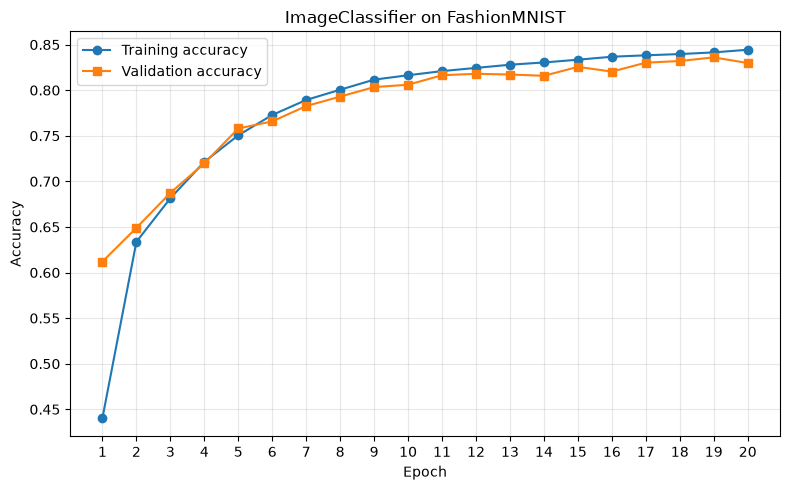

In [9]:
plot_accuracy(history)
plt.show()

## 5. Test-set evaluation (`05_evaluate.py`)

Evaluate the trained model on the 10,000-image test set, which was not used during training or validation, and report the final test accuracy.

In [10]:
test_acc = evaluate_tm(model, test_loader, accuracy, device)
print(f"Test accuracy: {test_acc:.4f} ({test_acc:.2%})")

Test accuracy: 0.8246 (82.46%)
